In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from tqdm.auto import tqdm

In [2]:
def GaussianRBFKernel(lengthscale):
    def k(x, y):
        x = np.atleast_2d(x)
        y = np.atleast_2d(y)
        # Compute squared Euclidean distances; broadcasting creates a (n, m) array
        diff = x[:, None, :] - y[None, :, :]
        sq_dist = np.sum(diff**2, axis=-1)
        return np.exp(-0.5 * sq_dist / (lengthscale ** 2))
    return k


In [22]:
class GaussianProcess():
    def __init__(self,d,kernel_function):
        self.k = kernel_function
        self.X = np.empty((0,d))
        self.y = np.empty((0,))
        self.d = d

    
    def update(self,x,y,sigma2 = 1e-7):
        """
        Update representation of the posterior
        """
        self.X = np.vstack([self.X,x.reshape(-1,self.d)])
        self.y = np.hstack([self.y,y])
        self.K = self.k(self.X,self.X) + sigma2*np.eye(len(self.X))
        self.P = np.linalg.inv(self.K)
    
    def posterior_mean(self,x):
        """
        Evaluate the posterior mean
        """
        
        Keval = self.k(np.atleast_2d(x),self.X)
        return Keval@self.P@self.y

    def posterior_cov(self,x,y):
        """
        Evaluate the posterior covariance
        """
        xx = np.atleast_2d(x)
        yy = np.atleast_2d(y)
        return self.k(xx,yy) - self.k(xx,self.X)@self.P@self.k(self.X,yy)
    
    def posterior_var(self,x):
        """
        Evaluate the posterior variance
        """
        xx = np.atleast_2d(x)
        return np.maximum(np.diag(self.posterior_cov(xx,xx)),1e-8)
    
    def sample_posterior(self,x_points):
        """
        Draw a sample from the posterior
        """
        mu = self.posterior_mean(x_points)
        cov = self.posterior_cov(x_points,x_points)
        return np.random.multivariate_normal(mu,cov)


def exp_improve_base(x_mean,x_var,best_y):
    z = (x_mean - best_y) / np.sqrt(x_var)

    ei = (
        (x_mean - best_y) * norm.cdf(z) 
        - np.sqrt(x_var) * norm.pdf(z)
    )
    return ei

def build_expected_improvement_fun(gp_posterior:GaussianProcess,best_y_so_far):
    def expected_improvement(x):
        return exp_improve_base(
            gp_posterior.posterior_mean(x),
            gp_posterior.posterior_var(x),
            best_y_so_far
            )
    return expected_improvement

def get_next_acquisition_point(
        gp_posterior,
        best_y_so_far, 
        lower_bounds,
        upper_bounds,
        num_samples = 50
        ):
    """
    Run some optimization or sampling code in here
    """
    ...

    x_candidates = np.random.uniform(lower_bounds,upper_bounds,(num_samples,len(lower_bounds)))
    ei_func = build_expected_improvement_fun(gp_posterior,best_y_so_far)
    ei_vals = ei_func(x_candidates)
    #Sample num_samples then optimize the best
    opt_result = minimize(
        ei_func,
        x_candidates[np.argmin(ei_vals)],
        bounds = zip(lower_bounds,upper_bounds),
        )
    return opt_result.x

def solve_with_bayes_opt(
        f,
        gp_prior:GaussianProcess,
        initial_acquisition_points,
        lower_bounds,
        upper_bounds,
        num_iter = 200
        ):    

    #Perform initial function evaluations
    #with initial acquisition points
    gp = gp_prior
    best_so_far = np.inf
    print("Computing initial observations:")
    for i,p in tqdm(enumerate(initial_acquisition_points)):
        y = f(p)
        if i==0:
            best_so_far = y 
            best_x = p
        else:
            if y<best_so_far:
                best_so_far = y
                best_x = p
        gp.update(p,y)
    print(f"Best so far: {best_so_far:.4f}")
    
    loss_vals = [best_so_far]
    
    
    for i in tqdm(range(num_iter)):
        ac_point = get_next_acquisition_point(gp,best_so_far,lower_bounds,upper_bounds)
        y = f(ac_point)
        gp.update(ac_point,y)
        if y<best_so_far:
            best_so_far = y
            best_x = ac_point
            loss_vals.append(y)
            print(f"New Best at Iter {i}: {y:.4f}")
    
    return best_x,best_so_far,loss_vals

## Test a simple case of kernel regression

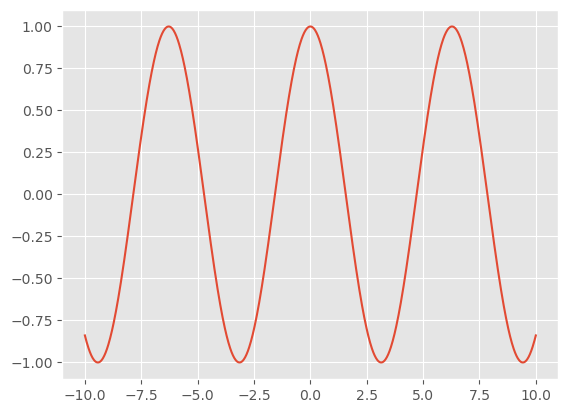

In [23]:
k = GaussianRBFKernel(1.)
gp = GaussianProcess(1,k)

#x needs to be two dimensional here
x_points = np.linspace(-10,10).reshape(-1,1)
y_points = np.cos(x_points)[:,0]
gp.update(x_points,y_points)
eval_x = np.linspace(-10,10,1000)
plt.plot(eval_x,gp.posterior_mean(eval_x.reshape(-1,1)))

Computing initial observations:


0it [00:00, ?it/s]

Best so far: -1.0164


  0%|          | 0/100 [00:00<?, ?it/s]

New Best at Iter 0: -1.0872
New Best at Iter 1: -1.2825
New Best at Iter 2: -1.4167
New Best at Iter 3: -1.4704
New Best at Iter 4: -1.5657
New Best at Iter 5: -1.6254
New Best at Iter 6: -1.6576
New Best at Iter 7: -1.6677
New Best at Iter 11: -1.6685
New Best at Iter 12: -1.6692
New Best at Iter 13: -1.6695
New Best at Iter 14: -1.6696
New Best at Iter 15: -1.6697
New Best at Iter 17: -1.6698
New Best at Iter 19: -1.6699
New Best at Iter 96: -1.6699
x solution:  [-0.33010542 -0.32519294]
f val:  -1.6698986347050664
Scipy Optimize Results
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.6699394631226947
        x: [-3.266e-01 -3.266e-01]
      nit: 4
      jac: [ 6.348e-06  6.348e-06]
 hess_inv: [[ 5.934e-01 -4.066e-01]
            [-4.066e-01  5.934e-01]]
     nfev: 18
     njev: 6


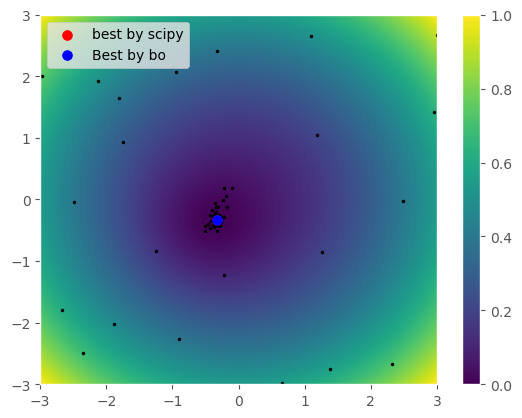

In [24]:
from test_functions import test_function_2d

f = test_function_2d

lower = np.array([-3,-3])
upper = np.array([3,3])
k = GaussianRBFKernel(0.25)
gp = GaussianProcess(2,k)
init_points = np.random.uniform(lower,upper,(20,len(lower)))

best_x,best_so_far,loss_vals = solve_with_bayes_opt(
    f = f,
    gp_prior = gp,
    initial_acquisition_points=init_points,
    lower_bounds=lower,
    upper_bounds=upper,
    num_iter=100
    )
print("x solution: ",best_x)
print("f val: ",best_so_far)

print("Scipy Optimize Results")
from scipy.optimize import minimize
min_result = minimize(f,np.array([0.,0]))
print(min_result)

xgrid = np.linspace(-3,3)
ygrid = np.linspace(-3,3)

xx,yy = np.meshgrid(xgrid,ygrid)
xy_points = np.hstack([xx.flatten()[:,None],yy.flatten()[:,None]])
fxy = [f(xy) for xy in xy_points]
plt.tricontourf(xy_points[:,0],xy_points[:,1],fxy,200)
plt.scatter(gp.X[:,0],gp.X[:,1],c='black',s=4)
plt.scatter(best_x[0],best_x[1],c = 'red',s=50,label = 'best by scipy')
plt.scatter(min_result.x[0],min_result.x[1],c = 'blue',s=50,label = 'Best by bo')
plt.legend()
plt.colorbar()

In [ ]:
from pde_inverse_problem import (
    tvals,x_grid,u_true,
    loss,forward_map,
    eval_locs,
    lower_bounds,
    upper_bounds,
    true_params
)
f = loss

k_base = GaussianRBFKernel(0.2)
width = upper - lower
def k(x,y):
    return k_base(x/width,y/width)

gp = GaussianProcess(len(lower_bounds),k)

lower = lower_bounds
upper = upper_bounds


num_init = 100
init_points = np.random.uniform(lower,upper,(num_init,len(lower)))

best_x,best_so_far,loss_vals = solve_with_bayes_opt(
    f = f,
    gp_prior = gp,
    initial_acquisition_points=init_points,
    lower_bounds=lower,
    upper_bounds=upper,
    num_iter= 300
    )

print("True Params: ",true_params)
print("x solution: ",best_x)
print("f val: ",best_so_far)


Computing initial observations:


0it [00:00, ?it/s]

Best so far: 0.9593


  0%|          | 0/300 [00:00<?, ?it/s]

New Best at Iter 9: 0.8898
New Best at Iter 13: 0.4001
New Best at Iter 30: 0.2399
New Best at Iter 53: 0.0481
New Best at Iter 63: 0.0322
New Best at Iter 72: 0.0176
New Best at Iter 74: 0.0067
New Best at Iter 79: 0.0022
New Best at Iter 90: 0.0017
New Best at Iter 93: 0.0011
New Best at Iter 97: 0.0006
New Best at Iter 181: 0.0006
True Params:  [ 0.4 -4.5  2.   3. ]
x solution:  [ 0.39983086 -4.46017013  2.07661294  2.99875429]
f val:  0.0005799406826234841


/Users/owlx/miniconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_array is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


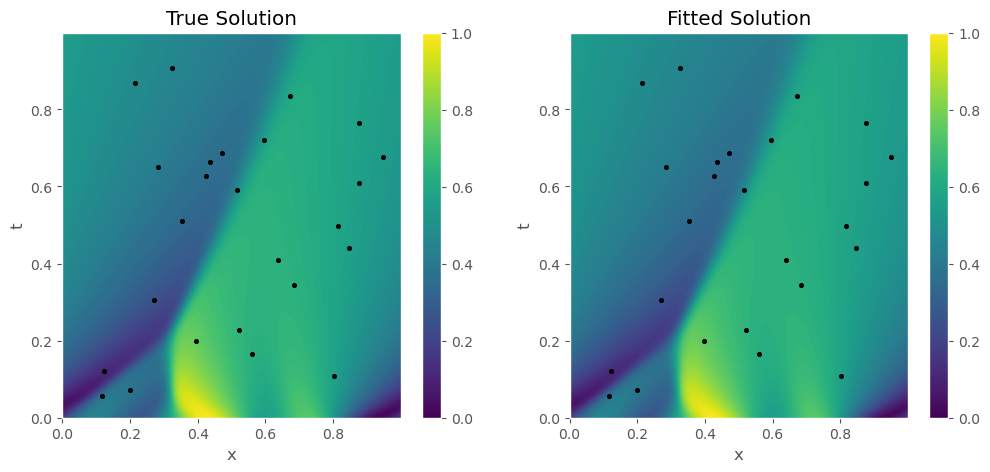

In [44]:
plt.figure(figsize=(12,5))
u_vals = u_true(tvals,x_grid)
plt.subplot(1,2,1)
plt.contourf(
    x_grid,tvals,u_vals,100
)
plt.scatter(eval_locs[:,0],eval_locs[:,1],c='black',label = "Observation Locations",s=10)
plt.xlabel('x')
plt.ylabel('t')
plt.title("True Solution")
plt.colorbar()

tvals,x_grid,u_approx = forward_map(best_x)
u_approx_vals = u_approx(tvals,x_grid)
plt.subplot(1,2,2)
plt.contourf(
    x_grid,tvals,u_approx_vals,100
)
plt.scatter(eval_locs[:,0],eval_locs[:,1],c='black',label = "Observation Locations",s=10)
plt.xlabel('x')
plt.ylabel('t')
plt.title("Fitted Solution")
plt.colorbar()
plt.show()